## Hücre Sırası
1. Imports + sabitler
2. 5 hastalık sınıfı + mapping (healthy, powdery_mildew, rust, blight, mold)
3. iNaturalist sabitler
4. iNaturalist fonksiyonlar
5. iNaturalist indirme çalıştırma
6. PlantVillage + PlantDoc + iNat birleştirme (5 sınıf veri klasörü, PV tavanı, manifest)
7. tf.data pipeline + augmentation (blight için yumuşatılmış)
8. Sınıf ağırlıkları (blight boost + mapping notu)
9. Model mimarisi (EfficientNetB3)
10. Aşama 1: Frozen backbone eğitimi
11. Aşama 2: Fine-tune
12. Değerlendirme + sınıf bazlı accuracy (+ blight özet)
13. Model + class_names kaydet
14. TFLite dönüştürme
15. TTA testi
16. Sonuçları JSON/CSV kaydet
17. Confusion Matrix (+ blight satır oranı)
18. Saha-proxsi test (PlantDoc+iNat, manifest)

In [1]:
# === 1. Imports + sabitler ===
import os, json, time, random, shutil
from pathlib import Path
import numpy as np
import warnings
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.efficientnet import preprocess_input

# === requests import (iNaturalist için) ===
import requests

# === Yol tanimlari (notebook nereden calisirsa calissin) ===
_cwd = Path.cwd().resolve()
if (_cwd / "requirements.txt").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "requirements.txt").exists():
    PROJECT_ROOT = _cwd.parent
elif (_cwd / "data").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "data").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
NAMES_DIR = PROJECT_ROOT / "class_names"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MANIFEST_CSV = OUTPUTS_DIR / "disease_image_manifest_5class.csv"
MODEL_STEM = "disease_5class"
for d in [MODELS_DIR, NAMES_DIR, OUTPUTS_DIR]:
    d.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)

# === Sabitler ===
# EfficientNetB3 ImageNet girdisi 300x300; backbone ile hizali tutulur
IMG_SIZE = (300, 300)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# --- Veri dengeleme + saha (lab %98 tuzaklarını azaltmak için) ---
# 5 sinif: PV sinif basina tavan + REBUILD ile eski birlesik klasoru sifirlama.
COMBINED_DATASET_NAME = "disease_combined_5class_v1"
# True: birleşik klasörü silip sıfırdan kopyala (tekrar çalıştırmada eski dosya birikimini önler)
REBUILD_COMBINED_DIR = True
# False ise PlantVillage bloğu atlanır (yalnızca PlantDoc+iNat; veri azalır)
USE_PLANTVILLAGE = True
# Her hastalık klasöründe en fazla kaç pv_* dosyası kalsın (0 = bu adımı kapat)
MAX_TRAIN_PV_PER_CLASS = 900
MAX_VAL_PV_PER_CLASS = 400
MAX_TEST_PV_PER_CLASS = 450
# Train'de healthy toplam tavanı (tüm kaynaklar sonrası)
MAX_TRAIN_DOMINANT_CLASS = 2800
DOMINANT_CLASSES_FOR_CAP = {"healthy"}
MAX_VAL_DOMINANT_CLASS = 900
SAVE_DATA_MANIFEST = True
# 5 sınıfta pest yok; dengeli class_weight yeter (True yaparsan yalnızca healthy hafif boost)
CONFUSE_PAIR_WEIGHT_TWEAK = False

PROJECT_ROOT: C:\Users\HP\Desktop\plant_project_hastalık\plant_project
TensorFlow: 2.21.0
GPU: []


In [2]:
# === 2. 5 hastalık sınıfı + PV/PD mapping ===
# healthy, powdery_mildew, rust, blight, mold — rot/scab/pest/kloroz yok.
# Not: Corn Cercospora gray leaf spot ve PlantDoc "Corn Gray leaf spot" blight etiketinden çıkarıldı (gürültü azaltma).
DISEASE_CLASSES = sorted([
    "blight",
    "healthy",
    "mold",
    "powdery_mildew",
    "rust",
])
NUM_CLASSES = len(DISEASE_CLASSES)

pv_mapping = {
    "Apple___Cedar_apple_rust": "rust",
    "Apple___healthy": "healthy",
    "Blueberry___healthy": "healthy",
    "Cherry_(including_sour)___healthy": "healthy",
    "Cherry_(including_sour)___Powdery_mildew": "powdery_mildew",
    # Cercospora gray leaf spot blight ile görsel olarak karışır; 5 sınıfta blight etiketine zorlamıyoruz.
    "Corn_(maize)___Common_rust_": "rust",
    "Corn_(maize)___healthy": "healthy",
    "Corn_(maize)___Northern_Leaf_Blight": "blight",
    "Grape___healthy": "healthy",
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)": "blight",
    "Peach___Bacterial_spot": "blight",
    "Peach___healthy": "healthy",
    "Pepper,_bell___Bacterial_spot": "blight",
    "Pepper,_bell___healthy": "healthy",
    "Potato___Early_blight": "blight",
    "Potato___healthy": "healthy",
    "Potato___Late_blight": "blight",
    "Raspberry___healthy": "healthy",
    "Soybean___healthy": "healthy",
    "Squash___Powdery_mildew": "powdery_mildew",
    "Strawberry___healthy": "healthy",
    "Strawberry___Leaf_scorch": "blight",
    "Tomato___Bacterial_spot": "blight",
    "Tomato___Early_blight": "blight",
    "Tomato___healthy": "healthy",
    "Tomato___Late_blight": "blight",
    "Tomato___Leaf_Mold": "mold",
    "Tomato___Septoria_leaf_spot": "blight",
    "Tomato___Target_Spot": "blight",
}

pd_mapping = {
    "Apple leaf": "healthy",
    "Apple rust leaf": "rust",
    "Bell_pepper leaf": "healthy",
    "Bell_pepper leaf spot": "blight",
    "Blueberry leaf": "healthy",
    "Cherry leaf": "healthy",
    # PlantDoc "Corn Gray leaf spot" blight ile tutarsız; eğitimden çıkarıldı.
    "Corn leaf blight": "blight",
    "Corn rust leaf": "rust",
    "grape leaf": "healthy",
    "Peach leaf": "healthy",
    "Potato leaf": "healthy",
    "Potato leaf early blight": "blight",
    "Potato leaf late blight": "blight",
    "Raspberry leaf": "healthy",
    "Soybean bacterial blight": "blight",
    "Soyabean leaf": "healthy",
    "Soybean leaf": "healthy",
    "Squash Powdery mildew leaf": "powdery_mildew",
    "Strawberry leaf": "healthy",
    "Strawberry leaf scorch": "blight",
    "Tomato Early blight leaf": "blight",
    "Tomato Septoria leaf spot": "blight",
    "Tomato leaf": "healthy",
    "Tomato leaf bacterial spot": "blight",
    "Tomato leaf late blight": "blight",
    "Tomato mold leaf": "mold",
}

CLASS_INDEX = {name: idx for idx, name in enumerate(DISEASE_CLASSES)}
print(f"DISEASE_CLASSES: {DISEASE_CLASSES}")
print(f"NUM_CLASSES: {NUM_CLASSES}")

DISEASE_CLASSES: ['blight', 'healthy', 'mold', 'powdery_mildew', 'rust']
NUM_CLASSES: 5


In [3]:
# === 3. iNaturalist hastalık görüntü indirme — sabitler ===
# Research-grade gözlemler; mevcut dosyalar atlanır (yeniden çalıştırmada devam)
# Hastalıklar için genel arama terimleri kullanıyoruz

INAT_DISEASE_DIR = DATA_DIR / "inat_disease_images"
INAT_DISEASE_DIR.mkdir(exist_ok=True)

# Hastalık sınıfı -> iNaturalist arama terimleri
disease_search_terms = {
    "powdery_mildew": ["powdery mildew", "Erysiphales"],
    "rust": ["rust fungus", "Pucciniales"],
    "mold": ["leaf mold", "Botrytis leaf", "gray mold leaf"],
    "blight": ["early blight", "late blight", "leaf blight"],
    # healthy icin iNat aramasi yok (yalnizca bu 4 hastalik)
}

print(f"{len(disease_search_terms)} hastalık sınıfı için iNaturalist indirme hazır.")

4 hastalık sınıfı için iNaturalist indirme hazır.


In [4]:
# === 4. iNaturalist hastalık görüntü indirme — fonksiyonlar ===

def get_taxon_id_disease(disease_name):
    # Hastalık için genel taxon arama (zor olabilir)
    r = requests.get(
        "https://api.inaturalist.org/v1/taxa",
        params={"q": disease_name, "per_page": 5},
        headers={"Accept": "application/json"},
        timeout=15,
    )
    for res in r.json().get("results", []):
        if res.get("name", "").lower() == disease_name.lower():
            return res["id"]
    return None

def download_disease_images(disease_class, search_terms, n_target=200):
    folder = INAT_DISEASE_DIR / disease_class
    folder.mkdir(exist_ok=True)
    existing = {p.stem for p in folder.glob("*.jpg")}
    if len(existing) >= n_target:
        return len(existing)

    downloaded = len(existing)
    for term in search_terms:
        if downloaded >= n_target:
            break
        
        # Genel hastalık arama (tür olmadan)
        for page in range(1, 5):
            if downloaded >= n_target:
                break
            try:
                r = requests.get(
                    "https://api.inaturalist.org/v1/observations",
                    params={
                        "q": term,
                        "quality_grade": "research",
                        "photos": "true",
                        "per_page": 100,
                        "page": page,
                        "order": "random",
                    },
                    headers={"Accept": "application/json"},
                    timeout=30,
                )
                obs_list = r.json().get("results", [])
            except Exception as e:
                print(f"  Hata ({term}, sayfa {page}): {e}")
                break
            if not obs_list:
                break

            for obs in obs_list:
                if downloaded >= n_target:
                    break
                photos = obs.get("photos", [])
                if not photos:
                    continue
                pid = str(photos[0].get("id", ""))
                if pid in existing:
                    continue
                url = photos[0].get("url", "").replace("/square.", "/medium.")
                if not url.startswith("http"):
                    continue
                try:
                    img_r = requests.get(url, timeout=20)
                    if img_r.status_code == 200 and len(img_r.content) > 5000:
                        (folder / f"{pid}.jpg").write_bytes(img_r.content)
                        existing.add(pid)
                        downloaded += 1
                except:
                    pass
                time.sleep(0.15)

            time.sleep(0.7)

    return downloaded

print("iNaturalist fonksiyonları tanımlandı.")

iNaturalist fonksiyonları tanımlandı.


In [5]:
# === 5. iNaturalist hastalık görüntü indirme — çalıştırma ===
# Tüm hastalık sınıfları için iNaturalist indirme
print(f"{len(disease_search_terms)} hastalık sınıfı için iNaturalist indirme başlıyor (healthy hariç)...")
print("Blight/mold hedef ~450; powdery_mildew/rust hedef ~300. Kesintide yeniden calistir, devam eder.\n")

for disease, terms in disease_search_terms.items():
    target = 450 if disease in ("blight", "mold") else 300
    n = download_disease_images(disease, terms, n_target=target)
    print(f"[{disease:20s}] {n} görüntü (hedef: {target})")
    time.sleep(0.5)

print("\nİndirme tamamlandı!")
print(f"Toplam indirilen: {sum(len(list((INAT_DISEASE_DIR / d).glob('*.jpg'))) for d in disease_search_terms.keys())}")

4 hastalık sınıfı için iNaturalist indirme başlıyor (healthy hariç)...
Blight/mold hedef ~450; powdery_mildew/rust hedef ~300. Kesintide yeniden calistir, devam eder.

[powdery_mildew      ] 300 görüntü (hedef: 300)
[rust                ] 300 görüntü (hedef: 300)
[mold                ] 403 görüntü (hedef: 450)
[blight              ] 450 görüntü (hedef: 450)

İndirme tamamlandı!
Toplam indirilen: 1453


In [6]:
# === 6. PlantVillage + PlantDoc + iNat (5 sinif, pv_* tavanı, manifest) ===
import hashlib

PV_RAW = DATA_DIR / "raw" / "plantvillage" / "dataset" / "New Plant Diseases Dataset(Augmented)"
PD_RAW = DATA_DIR / "raw" / "plantdoc"

OUT_DISEASE = DATA_DIR / COMBINED_DATASET_NAME

if REBUILD_COMBINED_DIR and OUT_DISEASE.exists():
    shutil.rmtree(OUT_DISEASE)
    print(f"Eski birleşik klasör silindi: {OUT_DISEASE}")

# Klasörleri oluştur
for split in ["train", "val", "test"]:
    (OUT_DISEASE / split).mkdir(parents=True, exist_ok=True)
    for disease in DISEASE_CLASSES:
        (OUT_DISEASE / split / disease).mkdir(exist_ok=True)

print(f"Çıktı klasörü: {OUT_DISEASE}")

# Görüntü uzantıları
_img_suffixes = {".jpg", ".jpeg", ".png", ".webp"}

def _safe_win_dst_name(name: str, max_len: int = 200) -> str:
    """Windows dosya adında yasak karakterleri temizler (WinError 3 / geçersiz yol)."""
    _bad = set('<>:"|?*') | {chr(47), chr(92)}
    s = "".join("_" if c in _bad or ord(c) < 32 else c for c in name)
    s = s.rstrip(" .")
    if not s:
        s = "_unnamed"
    return s[:max_len]


# Windows MAX_PATH (~260) — uzun proje yolu + PlantDoc dosya adları WinError 3 üretir
_WIN_MAX_DST = 230


def _short_tagged_basename(name_prefix: str, img_name: str) -> str:
    """Kaynak etiketi korunur: pv_ / pd_ / inat_ + hash + uzantı (yol kısaltma)."""
    suf = Path(img_name).suffix.lower() or ".jpg"
    key = hashlib.sha256(f"{name_prefix}|{img_name}".encode("utf-8", errors="replace")).hexdigest()[:24]
    if name_prefix.startswith("pv_"):
        return f"pv_{key}{suf}"
    if name_prefix.startswith("pd_"):
        return f"pd_{key}{suf}"
    if name_prefix.startswith("inat"):
        return f"inat_{key}{suf}"
    return _safe_win_dst_name(f"{name_prefix}__{img_name}")


def _copy_tagged_list(files, dst_dir: Path, name_prefix: str) -> int:
    """Dosyaları benzersiz adla kopyala (pv_/pd_/inat_ öneki → manifest kaynağı)."""
    dst_dir.mkdir(parents=True, exist_ok=True)
    try:
        _base = len(str(dst_dir.resolve())) + 1
    except OSError:
        _base = len(str(dst_dir)) + 1
    n = 0
    for img in files:
        img = Path(img)
        if not img.is_file() or img.suffix.lower() not in _img_suffixes:
            continue
        long_name = _safe_win_dst_name(f"{name_prefix}__{img.name}")
        if _base + len(long_name) > _WIN_MAX_DST:
            dst_name = _short_tagged_basename(name_prefix, img.name)
        else:
            dst_name = long_name
        dst_path = dst_dir / dst_name
        try:
            shutil.copy2(img, dst_path)
            n += 1
        except OSError as e:
            print(f"UYARI kopya atlandı: {e}\n  src={img}\n  dst={dst_path}")
    return n


def _undersample_class_folder(split: str, disease: str, max_keep: int) -> None:
    if max_keep is None or max_keep <= 0:
        return
    folder = OUT_DISEASE / split / disease
    if not folder.is_dir():
        return
    files = [f for f in folder.iterdir() if f.is_file() and f.suffix.lower() in _img_suffixes]
    if len(files) <= max_keep:
        return
    random.shuffle(files)
    for f in files[max_keep:]:
        f.unlink()


def _undersample_name_prefix_in_folder(split: str, disease: str, name_prefix: str, max_keep: int) -> None:
    """Yalnızca dosya adı name_prefix ile başlayanları tavana indir (ör. PlantVillage: pv_)."""
    if max_keep is None or max_keep <= 0:
        return
    folder = OUT_DISEASE / split / disease
    if not folder.is_dir():
        return
    tagged = [f for f in folder.iterdir() if f.is_file() and f.suffix.lower() in _img_suffixes and f.name.startswith(name_prefix)]
    if len(tagged) <= max_keep:
        return
    random.shuffle(tagged)
    for f in tagged[max_keep:]:
        f.unlink()


def _rebuild_manifest_from_disk():
    rows = []
    for split in ["train", "val", "test"]:
        for disease in DISEASE_CLASSES:
            folder = OUT_DISEASE / split / disease
            if not folder.is_dir():
                continue
            for f in folder.iterdir():
                if not f.is_file() or f.suffix.lower() not in _img_suffixes:
                    continue
                name = f.name
                if name.startswith("pv_"):
                    src = "plantvillage"
                elif name.startswith("pd_"):
                    src = "plantdoc"
                elif name.startswith("inat_"):
                    src = "inat"
                else:
                    src = "unknown"
                rel = Path(split) / disease / name
                rows.append({
                    "split": split,
                    "disease": disease,
                    "filename": name,
                    "source": src,
                    "relpath": "/".join(rel.parts),
                })
    return rows


# PlantVillage verilerini kopyala (USE_PLANTVILLAGE=False ise atlanır)
if USE_PLANTVILLAGE:
    print("\nPlantVillage verilerini kopyalanıyor...")
    pv_train_dir = PV_RAW / "train"
    pv_valid_dir = PV_RAW / "valid"

    for pv_class_name in pv_train_dir.iterdir():
        if not pv_class_name.is_dir():
            continue
        pv_class = pv_class_name.name
        target_disease = pv_mapping.get(pv_class, None)
        if not target_disease:
            continue

        src_train = pv_train_dir / pv_class
        dst_train = OUT_DISEASE / "train" / target_disease
        train_imgs = [f for f in src_train.iterdir() if f.is_file() and f.suffix.lower() in _img_suffixes]
        _copy_tagged_list(train_imgs, dst_train, f"pv_{pv_class}")

        src_val_orig = pv_valid_dir / pv_class
        if src_val_orig.exists():
            imgs = [f for f in src_val_orig.iterdir() if f.is_file() and f.suffix.lower() in _img_suffixes]
            random.shuffle(imgs)
            mid = len(imgs) // 2
            _copy_tagged_list(imgs[:mid], OUT_DISEASE / "val" / target_disease, f"pv_{pv_class}")
            _copy_tagged_list(imgs[mid:], OUT_DISEASE / "test" / target_disease, f"pv_{pv_class}")

    print("PlantVillage tamamlandı.")
else:
    print("\nPlantVillage atlandı (USE_PLANTVILLAGE=False).")

# PlantDoc verilerini kopyala
print("\nPlantDoc verilerini kopyalanıyor...")
if not PD_RAW.is_dir():
    raise FileNotFoundError(
        f"PlantDoc klasörü yok: {PD_RAW}\n"
        "Beklenen: data/raw/plantdoc/train ve .../test (PlantDoc veri seti)."
    )
pd_train_dir = PD_RAW / "train"
pd_test_dir = PD_RAW / "test"
if not pd_train_dir.is_dir():
    raise FileNotFoundError(f"PlantDoc train yok: {pd_train_dir}")
if not pd_test_dir.is_dir():
    raise FileNotFoundError(f"PlantDoc test yok: {pd_test_dir}")

# PlantDoc Train -> OUT Train
for pd_class_name in pd_train_dir.iterdir():
    if not pd_class_name.is_dir():
        continue
    pd_class = pd_class_name.name
    target_disease = pd_mapping.get(pd_class, None)
    if not target_disease:
        continue
    pd_imgs = [f for f in (pd_train_dir / pd_class).iterdir() if f.is_file() and f.suffix.lower() in _img_suffixes]
    _copy_tagged_list(pd_imgs, OUT_DISEASE / "train" / target_disease, f"pd_{pd_class}")

# PlantDoc Test -> OUT Val ve OUT Test olarak böl
for pd_class_name in pd_test_dir.iterdir():
    if not pd_class_name.is_dir():
        continue
    pd_class = pd_class_name.name
    target_disease = pd_mapping.get(pd_class, None)
    if not target_disease:
        continue

    src = pd_test_dir / pd_class
    imgs = [img for img in src.iterdir() if img.is_file() and img.suffix.lower() in _img_suffixes]
    random.shuffle(imgs)
    
    # %50 val, %50 test — önekli kopya (manifest `plantdoc` + saha-proxsi testi için)
    mid = len(imgs) // 2
    _copy_tagged_list(imgs[:mid], OUT_DISEASE / "val" / target_disease, f"pd_{pd_class}")
    _copy_tagged_list(imgs[mid:], OUT_DISEASE / "test" / target_disease, f"pd_{pd_class}")

print("PlantDoc tamamlandı.")

# iNaturalist hastalık görüntülerini ekle
print("\niNaturalist hastalık görüntüleri ekleniyor...")
for disease in DISEASE_CLASSES:
    if disease == "healthy":
        continue
    inat_dir = INAT_DISEASE_DIR / disease
    if not inat_dir.exists():
        continue

    imgs = [img for img in inat_dir.iterdir() if img.is_file() and img.suffix.lower() == ".jpg"]
    random.shuffle(imgs)
    
    # Oranlar: %80 Train, %10 Val, %10 Test
    n_total = len(imgs)
    n_val = max(1, n_total // 10)
    n_test = max(1, n_total // 10)

    _copy_tagged_list(imgs[:n_test], OUT_DISEASE / "test" / disease, "inat")
    _copy_tagged_list(imgs[n_test:n_test + n_val], OUT_DISEASE / "val" / disease, "inat")
    _copy_tagged_list(imgs[n_test + n_val:], OUT_DISEASE / "train" / disease, "inat")

print("iNaturalist tamamlandı.")

# PlantVillage: sınıf klasörü başına pv_* tavanı (lab dominasyonunu kırar; 0=kapalı)
print("\n--- PlantVillage (pv_*) split başına tavan ---")
_pv_plan = [
    ("train", MAX_TRAIN_PV_PER_CLASS),
    ("val", MAX_VAL_PV_PER_CLASS),
    ("test", MAX_TEST_PV_PER_CLASS),
]
for _split, _cap in _pv_plan:
    if _cap is None or _cap <= 0:
        continue
    for _d in DISEASE_CLASSES:
        _undersample_name_prefix_in_folder(_split, _d, "pv_", _cap)
print("PV tavanı bitti (USE_PLANTVILLAGE=False veya tavan=0 ise etkisiz olabilir).")

# healthy train+val tavanı (Hücre 1'deki sabitler)
print("\n--- Baskın sınıf undersampling ---")
for d in DISEASE_CLASSES:
    if d in DOMINANT_CLASSES_FOR_CAP:
        _undersample_class_folder("train", d, MAX_TRAIN_DOMINANT_CLASS)
        _undersample_class_folder("val", d, MAX_VAL_DOMINANT_CLASS)
print("Undersampling tamamlandı.")

if SAVE_DATA_MANIFEST:
    _mr = _rebuild_manifest_from_disk()
    _mp = MANIFEST_CSV
    pd.DataFrame(_mr).to_csv(_mp, index=False, encoding="utf-8-sig")
    print(f"Manifest: {_mp} ({len(_mr)} satır)")

def _count_images(split: str, disease: str) -> int:
    p = OUT_DISEASE / split / disease
    if not p.is_dir():
        return 0
    return sum(1 for f in p.iterdir() if f.is_file() and f.suffix.lower() in _img_suffixes)

print("\n=== Veri İstatistikleri ===")
for split in ["train", "val", "test"]:
    total = sum(_count_images(split, d) for d in DISEASE_CLASSES)
    print(f"{split:5s}: {total:>6} görüntü ({total // len(DISEASE_CLASSES):.0f} ort./sınıf)")
    for disease in DISEASE_CLASSES:
        n = _count_images(split, disease)
        print(f"  {disease:25s}: {n:>5}")


Eski birleşik klasör silindi: C:\Users\HP\Desktop\plant_project_hastalık\plant_project\data\disease_combined_5class_v1
Çıktı klasörü: C:\Users\HP\Desktop\plant_project_hastalık\plant_project\data\disease_combined_5class_v1

PlantVillage verilerini kopyalanıyor...
PlantVillage tamamlandı.

PlantDoc verilerini kopyalanıyor...
PlantDoc tamamlandı.

iNaturalist hastalık görüntüleri ekleniyor...
iNaturalist tamamlandı.

--- PlantVillage (pv_*) split başına tavan ---
PV tavanı bitti (USE_PLANTVILLAGE=False veya tavan=0 ise etkisiz olabilir).

--- Baskın sınıf undersampling ---
Undersampling tamamlandı.
Manifest: C:\Users\HP\Desktop\plant_project_hastalık\plant_project\outputs\disease_image_manifest_5class.csv (11936 satır)

=== Veri İstatistikleri ===
train:   7604 görüntü (1520 ort./sınıf)
  blight                   :  2100
  healthy                  :  1624
  mold                     :  1302
  powdery_mildew           :  1260
  rust                     :  1318
val  :   2072 görüntü (414 or

In [7]:
# === 7. tf.data pipeline + augmentation ===
# Yumuşatılmış augmentation + EfficientNet preprocess (blight lezyonu korunur).

TRAIN_DIR = str(OUT_DISEASE / "train")
VAL_DIR = str(OUT_DISEASE / "val")
TEST_DIR = str(OUT_DISEASE / "test")

# Yumuşatılmış augmentation: blight lezyonları kaybolmasın (önceki agresif değerler düşürüldü).
aug_layer = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.18),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.18),
        layers.RandomBrightness(0.14),
        layers.RandomTranslation(0.08, 0.08),
        layers.RandomSaturation(0.15),
        layers.RandomHue(0.05),
        layers.GaussianNoise(stddev=0.012),
    ],
    name="augmentation",
)


def make_dataset(directory, shuffle=False, augment=False):
    ds = keras.utils.image_dataset_from_directory(
        directory,
        labels="inferred",
        label_mode="int",
        class_names=DISEASE_CLASSES,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED,
    )

    def train_step(img, label):
        x = tf.cast(img, tf.float32)
        x = aug_layer(x, training=True)
        x = preprocess_input(x)
        return x, label

    def eval_step(img, label):
        x = tf.cast(img, tf.float32)
        x = preprocess_input(x)
        return x, label

    if augment:
        ds = ds.map(train_step, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(eval_step, num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)


train_ds = make_dataset(TRAIN_DIR, shuffle=True, augment=True)
val_ds = make_dataset(VAL_DIR, shuffle=False, augment=False)
test_ds = make_dataset(TEST_DIR, shuffle=False, augment=False)

print("Train:", int(train_ds.cardinality().numpy()), "batch")
print("Val:  ", int(val_ds.cardinality().numpy()), "batch")
print("Test: ", int(test_ds.cardinality().numpy()), "batch")

Found 7604 files belonging to 5 classes.
Found 2072 files belonging to 5 classes.
Found 2260 files belonging to 5 classes.
Train: 238 batch
Val:   65 batch
Test:  71 batch


In [8]:
# === 8. Sınıf ağırlıkları ===
from sklearn.utils.class_weight import compute_class_weight

all_labels = []
for _, labels in train_ds.unbatch():
    all_labels.append(int(labels.numpy()))
all_labels = np.array(all_labels)

weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=all_labels)
class_weight_dict = {i: float(w) for i, w in enumerate(weights)}

if globals().get("CONFUSE_PAIR_WEIGHT_TWEAK", False):
    _hi = CLASS_INDEX.get("healthy")
    if _hi is not None:
        class_weight_dict[_hi] *= 1.12
    print("CONFUSE_PAIR_WEIGHT_TWEAK: healthy agirligi hafif artirildi.")

# Blight -> healthy kaymasını azalt: blight ağırlığını artır, healthy'yi hafif düşür.
_ibl = CLASS_INDEX.get("blight")
_ihh = CLASS_INDEX.get("healthy")
if _ibl is not None:
    class_weight_dict[_ibl] *= 1.35
if _ihh is not None:
    class_weight_dict[_ihh] *= 0.92
print("BLIGHT_WEIGHT_TUNING: blight *1.35, healthy *0.92 (balanced sonrası).")

print(f"Ağırlık aralığı: {min(class_weight_dict.values()):.3f} - {max(class_weight_dict.values()):.3f}")
print("\nSınıf Ağırlıkları:")
for disease, idx in CLASS_INDEX.items():
    print(f"  {disease:25s}: {class_weight_dict[idx]:.3f}")

BLIGHT_WEIGHT_TUNING: blight *1.35, healthy *0.92 (balanced sonrası).
Ağırlık aralığı: 0.862 - 1.207

Sınıf Ağırlıkları:
  blight                   : 0.978
  healthy                  : 0.862
  mold                     : 1.168
  powdery_mildew           : 1.207
  rust                     : 1.154


In [9]:
# === 9. Model mimarisi (EfficientNetB3) ===
# ImageNet pretrained backbone -> GAP -> Dropout(0.4) -> Dense(softmax)

base_model = keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,),
)
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax",
                       kernel_regularizer=keras.regularizers.l2(1e-4))(x)

model = keras.Model(inputs, outputs)
model.summary(line_length=80, show_trainable=True)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape           ┃     Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 300, 300, 3)    │           0 │   -   │
├───────────────────────────────┼────────────────────────┼─────────────┼───────┤
│ efficientnetb3 (Functional)   │ (None, 10, 10, 1536)   │  10,783,535 │   N   │
├───────────────────────────────┼────────────────────────┼─────────────┼───────┤
│ global_average_pooling2d      │ (None, 1536)           │           0 │   -   │
│ (GlobalAveragePooling2D)      │                        │             │       │
├───────────────────────────────┼────────────────────────┼─────────────┼───────┤
│ dropout (Dropout)             │ (None, 1536)           │           0 │   -   │
├───────────────────────────────┼────────────────────────┼─────────────┼───────┤
│ dense (Dense)                 │ (None, 5)              │       7,685 │   Y   │
└───────────────────────────────┴────────────────────────┴─────────────┴───────┘

 Total params: 10,791,220 (41.17 MB)

 Trainable params: 7,685 (30.02 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [10]:
# === 10. Aşama 1: Frozen backbone eğitimi ===

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cb_checkpoint = keras.callbacks.ModelCheckpoint(
    str(MODELS_DIR / "disease_5class_stage1.keras"),
    save_best_only=True, monitor="val_accuracy", verbose=1,
)
cb_earlystop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=4, restore_best_weights=True, verbose=1,
)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[cb_checkpoint, cb_earlystop],
    class_weight=class_weight_dict,
)

print("\nAşama 1 tamamlandı.")
print(f"En iyi val_acc: {max(history1.history['val_accuracy']):.4f}")

Epoch 1/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4707 - loss: 1.3455
Epoch 1: val_accuracy improved from None to 0.76448, saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\disease_5class_stage1.keras

Epoch 1: finished saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\disease_5class_stage1.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 370s 1s/step - accuracy: 0.5831 - loss: 1.1382 - val_accuracy: 0.7645 - val_loss: 0.7331
Epoch 2/10
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7026 - loss: 0.8923
Epoch 2: val_accuracy improved from 0.76448 to 0.80695, saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\disease_5class_stage1.keras

Epoch 2: finished saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\disease_5class_stage1.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 356s 1s/step - accuracy: 0.7115 - loss: 0.8651 - val_accuracy: 0.8069 - val_loss: 0.6130
Epoch 3/10
238/

In [11]:
# === 11. Aşama 2: Fine-tune ===
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 40
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Eğitilen katman: {trainable_count}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cb_checkpoint2 = keras.callbacks.ModelCheckpoint(
    str(MODELS_DIR / "disease_5class_best.keras"),
    save_best_only=True, monitor="val_accuracy", verbose=1,
)
cb_earlystop2 = keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=6, restore_best_weights=True, verbose=1,
)
cb_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1,
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[cb_checkpoint2, cb_earlystop2, cb_reduce_lr],
    class_weight=class_weight_dict,
)

print("\nAşama 2 tamamlandı.")
print(f"En iyi val_acc: {max(history2.history['val_accuracy']):.4f}")

Eğitilen katman: 5
Epoch 1/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6518 - loss: 0.9699
Epoch 1: val_accuracy improved from None to 0.83929, saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\disease_5class_best.keras

Epoch 1: finished saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\disease_5class_best.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 444s 2s/step - accuracy: 0.6710 - loss: 0.9241 - val_accuracy: 0.8393 - val_loss: 0.4786 - learning_rate: 1.0000e-05
Epoch 2/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7068 - loss: 0.8352
Epoch 2: val_accuracy improved from 0.83929 to 0.85618, saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\disease_5class_best.keras

Epoch 2: finished saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\disease_5class_best.keras
238/238 ━━━━━━━━━━━━━━━━━━━━ 441s 2s/step - accuracy: 0.7237 - loss: 0.8043 - val_accuracy: 0.

In [12]:
# === 12. Değerlendirme + sınıf bazlı accuracy ===

loss, acc = model.evaluate(test_ds, verbose=0)
print(f"Test Loss    : {loss:.4f}")
print(f"Test Accuracy: {acc:.4f}  ({acc*100:.1f}%)")

y_true, y_pred = [], []
for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

per_class = []
for i, disease in enumerate(DISEASE_CLASSES):
    mask = y_true == i
    if mask.sum() == 0:
        continue
    cls_acc = (y_pred[mask] == i).mean() * 100
    per_class.append({"Hastalık": disease, "Accuracy": round(cls_acc, 1), "Örnek": int(mask.sum())})

df = pd.DataFrame(per_class).sort_values("Accuracy")
print(f"\n%70 altı sınıflar: {(df['Accuracy'] < 70).sum()}")
print(f"%80 ve üstü sınıflar: {(df['Accuracy'] >= 80).sum()}")
print("\n--- SINIF BAZLI ACCURACY ---")
print(df.to_string(index=False))

# blight satırı özeti (confusion öncesi hızlı metrik)
_bi = CLASS_INDEX.get("blight")
if _bi is not None and len(y_true):
    m_b = y_true == _bi
    if m_b.sum() > 0:
        n_b, ok_b = int(m_b.sum()), int((y_pred[m_b] == _bi).sum())
        print(f"\n--- blight test özeti: {ok_b}/{n_b} doğru ({100.0*ok_b/n_b:.1f}%), yanlış {n_b-ok_b} ---")

# --- PlantVillage dışı test alt kümesi (manifest; uygulamaya daha yakın metrik) ---
_mp = MANIFEST_CSV
if _mp.exists():
    _mdf = pd.read_csv(_mp, encoding="utf-8-sig")
    _sub = _mdf[(_mdf["split"] == "test") & (_mdf["source"] != "plantvillage")]
    if len(_sub) == 0:
        print("\n(PV-dışı test: manifestte uygun satır yok)")
    else:
        _paths = [OUT_DISEASE / Path(r["relpath"]) for _, r in _sub.iterrows()]
        _labs = np.array([CLASS_INDEX[r["disease"]] for _, r in _sub.iterrows()], dtype=np.int32)
        _pairs = [(p, y) for p, y in zip(_paths, _labs) if p.is_file()]
        if not _pairs:
            print("\n(PV-dışı test: dosya yolları bulunamadı)")
        else:
            _ps, _ys = zip(*_pairs)
            _ys = np.array(_ys, dtype=np.int32)
            _pstr = [str(p) for p in _ps]

            def _load_np(path, label):
                img = tf.io.read_file(path)
                img = tf.image.decode_image(img, channels=3, expand_animations=False)
                img.set_shape([None, None, 3])
                img = tf.image.resize(img, IMG_SIZE)
                img = tf.cast(img, tf.float32)
                img = preprocess_input(img)
                return img, label

            _ds = tf.data.Dataset.from_tensor_slices((_pstr, _ys))
            _ds = _ds.map(_load_np, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
            _loss_np, _acc_np = model.evaluate(_ds, verbose=0)
            print(f"\nTest (PlantVillage HARİÇ, N={len(_pstr)}): acc={_acc_np*100:.2f}%, loss={_loss_np:.4f}")
else:
    print("\n(PV-dışı test: manifest yok — Hücre 6, SAVE_DATA_MANIFEST=True)")

Test Loss    : 0.1741
Test Accuracy: 0.9429  (94.3%)

%70 altı sınıflar: 0
%80 ve üstü sınıflar: 5

--- SINIF BAZLI ACCURACY ---
      Hastalık  Accuracy  Örnek
        blight      90.1    535
          mold      91.0    278
          rust      94.9    490
powdery_mildew      96.7    461
       healthy      97.8    496

--- blight test özeti: 482/535 doğru (90.1%), yanlış 53 ---

Test (PlantVillage HARİÇ, N=247): acc=75.30%, loss=0.7168


In [13]:
# === 13. Model + class_names kaydet ===
model_path = MODELS_DIR / "disease_5class_best.keras"
model.save(str(model_path))
print("Model kaydedildi:", model_path)

names_path = NAMES_DIR / "disease_class_names_5class.json"
with open(names_path, "w", encoding="utf-8") as f:
    json.dump(DISEASE_CLASSES, f, ensure_ascii=False, indent=2)
print("Class names kaydedildi:", names_path)

hist_all = dict(history1.history)
if "history2" in globals():
    for k, v in history2.history.items():
        hist_all[k] = hist_all.get(k, []) + v
with open(OUTPUTS_DIR / "training_history_disease_5class.json", "w", encoding="utf-8") as f:
    json.dump(hist_all, f, indent=2)
print("Eğitim geçmişi kaydedildi: training_history_disease_5class.json")

Model kaydedildi: C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\disease_5class_best.keras
Class names kaydedildi: C:\Users\HP\Desktop\plant_project_hastalık\plant_project\class_names\disease_class_names_5class.json
Eğitim geçmişi kaydedildi: training_history_disease_5class.json


In [14]:
# === 14. TFLite dönüştürme ===
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = []
tflite_model = converter.convert()

tflite_path = MODELS_DIR / "disease_5class.tflite"
tflite_path.write_bytes(tflite_model)
print(f"TFLite kaydedildi: {tflite_path}")
print(f"Boyut: {tflite_path.stat().st_size / 1024 / 1024:.1f} MB")

shutil.copy(str(NAMES_DIR / "disease_class_names_5class.json"), str(MODELS_DIR / "disease_class_names_5class.json"))
print("class_names.json modeller klasörüne kopyalandı.")

INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpnhltft1i\assets


INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpnhltft1i\assets


Saved artifact at 'C:\Users\HP\AppData\Local\Temp\tmpnhltft1i'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name='keras_tensor_395')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2618516216272: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2618516213584: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2618326712144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2618346259664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2618346259856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2618326710224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2618326711760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2618346258512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2618346258704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2618346259088: TensorSpec(shape=(), dtype=tf.resource,

In [15]:
# === 15. TTA testi ===

def predict_with_tta(model, img_batch, n_variants=8):
    variants = []
    for k in range(4):
        r = np.rot90(img_batch, k=k, axes=(1, 2))
        variants.append(np.array(r, copy=True))
        variants.append(np.array(r[:, :, ::-1, :], copy=True))
    preds = [model.predict(v, verbose=0) for v in variants[:n_variants]]
    return np.mean(preds, axis=0)


y_true_tta, y_pred_normal, y_pred_tta = [], [], []

for imgs, labels in test_ds:
    imgs_np = imgs.numpy()
    lbls_np = labels.numpy()
    p_normal = model.predict(imgs_np, verbose=0)
    p_tta = predict_with_tta(model, imgs_np)
    y_true_tta.extend(lbls_np)
    y_pred_normal.extend(np.argmax(p_normal, axis=1))
    y_pred_tta.extend(np.argmax(p_tta, axis=1))


y_true_tta = np.array(y_true_tta)
y_pred_normal = np.array(y_pred_normal)
y_pred_tta = np.array(y_pred_tta)

acc_normal = (y_pred_normal == y_true_tta).mean()
acc_tta = (y_pred_tta == y_true_tta).mean()

print(f"Normal Accuracy : {acc_normal:.4f}  ({acc_normal*100:.1f}%)")
print(f"TTA    Accuracy : {acc_tta:.4f}  ({acc_tta*100:.1f}%)")
print(f"TTA kazanımı    : +{(acc_tta - acc_normal)*100:.2f} puan")

Normal Accuracy : 0.9429  (94.3%)
TTA    Accuracy : 0.9447  (94.5%)
TTA kazanımı    : +0.18 puan


In [16]:
# === 16. Sonuçları JSON/CSV kaydet ===
from sklearn.metrics import classification_report

y_true_s, y_pred_s = [], []
for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0)
    y_true_s.extend(labels.numpy())
    y_pred_s.extend(np.argmax(preds, axis=1))
y_true_s = np.array(y_true_s)
y_pred_s = np.array(y_pred_s)

rows = []
for i, disease in enumerate(DISEASE_CLASSES):
    mask = y_true_s == i
    if mask.sum() == 0:
        continue
    rows.append({
        "Hastalık": disease,
        "Accuracy (%)": round((y_pred_s[mask] == i).mean() * 100, 1),
        "Doğru": int((y_pred_s[mask] == i).sum()),
        "Toplam": int(mask.sum()),
    })
df_all = pd.DataFrame(rows).sort_values("Accuracy (%)", ascending=False).reset_index(drop=True)
df_all.index += 1

csv_path = OUTPUTS_DIR / "per_class_accuracy_disease_5class.csv"
df_all.to_csv(csv_path, index=True, encoding="utf-8-sig")
print("CSV kaydedildi:", csv_path)

json_path = OUTPUTS_DIR / "per_class_accuracy_disease_5class.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(df_all.to_dict(orient="records"), f, ensure_ascii=False, indent=2)
print("JSON kaydedildi:", json_path)

clf_report = classification_report(y_true_s, y_pred_s, labels=range(NUM_CLASSES),
                                   target_names=DISEASE_CLASSES, output_dict=True)
clf_report_path = OUTPUTS_DIR / "classification_report_disease_5class.json"
with open(clf_report_path, "w", encoding="utf-8") as f:
    json.dump(clf_report, f, ensure_ascii=False, indent=2)
print(f"Classification report kaydedildi: {clf_report_path}")

metrics = {
    "Overall Accuracy": round((y_true_s == y_pred_s).mean() * 100, 2),
    "Total Samples": int(len(y_true_s)),
    "Correct Predictions": int((y_true_s == y_pred_s).sum()),
    "Macro Avg F1-Score": round(clf_report["macro avg"]["f1-score"], 4),
    "Weighted Avg F1-Score": round(clf_report["weighted avg"]["f1-score"], 4),
}
metrics_path = OUTPUTS_DIR / "metrics_disease_5class.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)
print(f"Metrikler kaydedildi: {metrics_path}")
print(f"\nGenel Doğruluk : %{metrics['Overall Accuracy']}")
print(f"F1 (Weighted)  : {metrics['Weighted Avg F1-Score']}")

CSV kaydedildi: C:\Users\HP\Desktop\plant_project_hastalık\plant_project\outputs\per_class_accuracy_disease_5class.csv
JSON kaydedildi: C:\Users\HP\Desktop\plant_project_hastalık\plant_project\outputs\per_class_accuracy_disease_5class.json
Classification report kaydedildi: C:\Users\HP\Desktop\plant_project_hastalık\plant_project\outputs\classification_report_disease_5class.json
Metrikler kaydedildi: C:\Users\HP\Desktop\plant_project_hastalık\plant_project\outputs\metrics_disease_5class.json

Genel Doğruluk : %94.29
F1 (Weighted)  : 0.9428


In [17]:
# Ne: Sinif bazli (per-class) accuracy raporu
# Neden: Genel accuracy yaniltici olabilir; hangi hastalik kategorisinin zayif oldugunu gormek icin

import numpy as np
import pandas as pd
import tensorflow as tf

# === KRİTİK: Model yolunu burada tanımlıyoruz ===
# Not: MODELS_DIR değişkeninin çalışması için notebook'un en başındaki 1. hücreyi çalıştırdığından emin ol.
MODEL_PATH = str(MODELS_DIR / "disease_5class_best.keras")

# En iyi modeli yukle
try:
    model = tf.keras.models.load_model(MODEL_PATH)
    print("Model başarıyla yüklendi:", MODEL_PATH)
except Exception as e:
    print(f"Hata: Model yüklenemedi. Yol doğru mu? {MODEL_PATH}")
    print("Hata detayı:", e)

# Test seti uzerinde tahmin
y_true_all, y_pred_all = [], []
for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0)
    y_true_all.extend(labels.numpy())
    y_pred_all.extend(np.argmax(preds, axis=1))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Genel accuracy
overall_acc = (y_true_all == y_pred_all).mean() * 100
print(f"\nGenel Test Accuracy: %{overall_acc:.2f}")
print("=" * 55)

# Sinif bazli accuracy
rows = []
for i, cls_name in enumerate(DISEASE_CLASSES):
    mask = y_true_all == i
    if mask.sum() == 0:
        continue
    cls_acc  = (y_pred_all[mask] == i).mean() * 100
    correct  = int((y_pred_all[mask] == i).sum())
    total    = int(mask.sum())
    rows.append({
        "Hastalik": cls_name,
        "Accuracy (%)": round(cls_acc, 1),
        "Dogru": correct,
        "Toplam": total,
    })

df_cls = (
    pd.DataFrame(rows)
    .sort_values("Accuracy (%)", ascending=False)
    .reset_index(drop=True)
)
df_cls.index += 1

print()
if df_cls.empty:
    print("Uyarı: test kümesinde etiketli örnek yok veya `DISEASE_CLASSES` eşleşmiyor.")
else:
    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 200)
    print(df_cls.to_string(index=True))
    print()
    print(f"En dusuk accuracy: {df_cls['Accuracy (%)'].min():.1f}%  -> {df_cls.iloc[-1]['Hastalik']}")
    print(f"En yuksek accuracy: {df_cls['Accuracy (%)'].max():.1f}%  -> {df_cls.iloc[0]['Hastalik']}")

    # CSV olarak kaydet
    csv_path = OUTPUTS_DIR / "per_class_accuracy_disease.csv"
    df_cls.to_csv(str(csv_path), index=True, encoding="utf-8-sig")
    print(f"\nCSV kaydedildi: {csv_path}")


Model başarıyla yüklendi: C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\disease_5class_best.keras

Genel Test Accuracy: %94.29

         Hastalik  Accuracy (%)  Dogru  Toplam
1         healthy          97.8    485     496
2  powdery_mildew          96.7    446     461
3            rust          94.9    465     490
4            mold          91.0    253     278
5          blight          90.1    482     535

En dusuk accuracy: 90.1%  -> blight
En yuksek accuracy: 97.8%  -> healthy

CSV kaydedildi: C:\Users\HP\Desktop\plant_project_hastalık\plant_project\outputs\per_class_accuracy_disease.csv


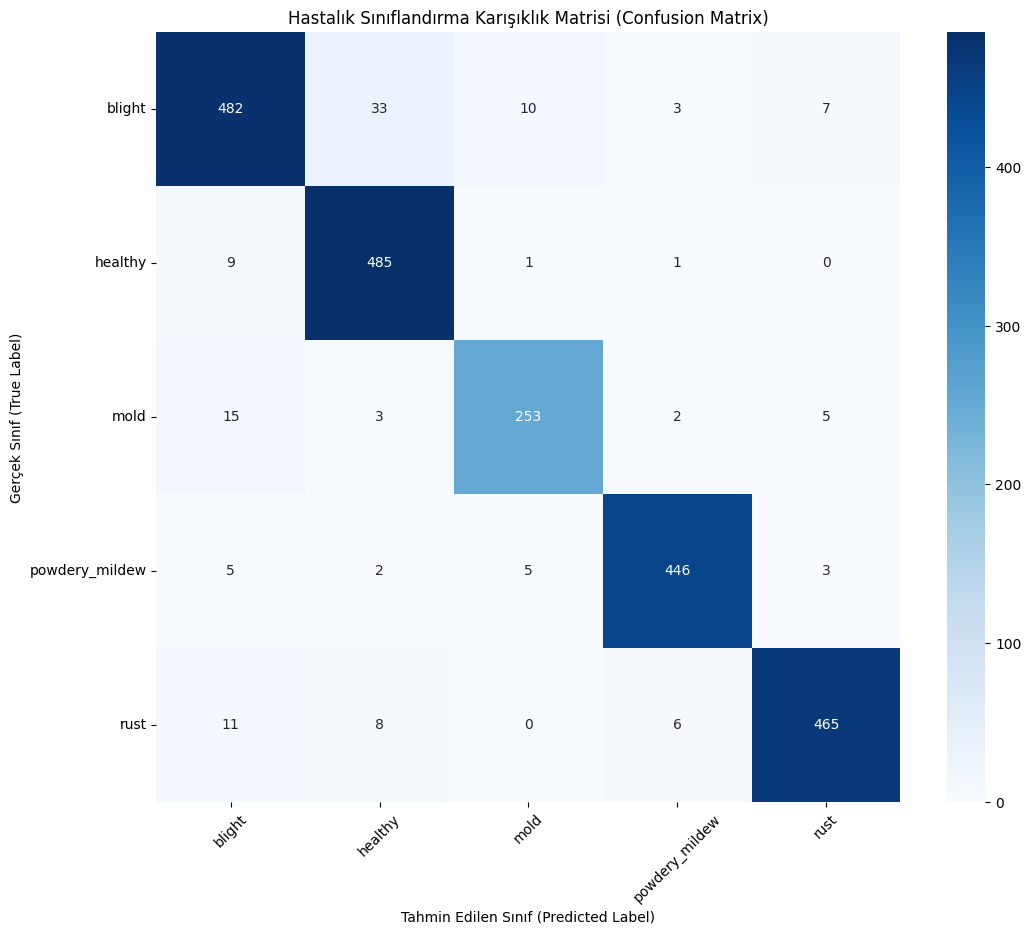


--- En Çok Karışan Sınıflar (Hata Analizi) ---
Gerçek: blight               | Tahmin: healthy              | Hata Sayısı: 33
Gerçek: blight               | Tahmin: mold                 | Hata Sayısı: 10
Gerçek: blight               | Tahmin: rust                 | Hata Sayısı: 7
Gerçek: healthy              | Tahmin: blight               | Hata Sayısı: 9
Gerçek: mold                 | Tahmin: blight               | Hata Sayısı: 15
Gerçek: rust                 | Tahmin: blight               | Hata Sayısı: 11
Gerçek: rust                 | Tahmin: healthy              | Hata Sayısı: 8
Gerçek: rust                 | Tahmin: powdery_mildew       | Hata Sayısı: 6

--- blight confusion satırı: doğru=482/535, yanlış oranı=9.9% ---


In [18]:
# === 17. Confusion Matrix (Karışıklık Matrisi) ===
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Eğer 16. hücreyi çalıştırdıysan y_true_s ve y_pred_s hazırdır. 
# Hazır değilse veya hata verirse diye kontrol ekliyoruz:
if 'y_true_s' not in globals() or 'y_pred_s' not in globals():
    print("Tahminler hafızada bulunamadı, yeniden hesaplanıyor...")
    y_true_s, y_pred_s = [], []
    for imgs, labels in test_ds:
        preds = model.predict(imgs, verbose=0)
        y_true_s.extend(labels.numpy())
        y_pred_s.extend(np.argmax(preds, axis=1))
    y_true_s = np.array(y_true_s)
    y_pred_s = np.array(y_pred_s)

# Matrisi hesapla
cm = confusion_matrix(y_true_s, y_pred_s)

# Görselleştirme
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=DISEASE_CLASSES, 
            yticklabels=DISEASE_CLASSES)

plt.title('Hastalık Sınıflandırma Karışıklık Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Sınıf (True Label)')
plt.xlabel('Tahmin Edilen Sınıf (Predicted Label)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# En çok karışanları listele (Opsiyonel)
print("\n--- En Çok Karışan Sınıflar (Hata Analizi) ---")
for i in range(len(DISEASE_CLASSES)):
    for j in range(len(DISEASE_CLASSES)):
        if i != j and cm[i, j] > 5: # 5'ten fazla yanlış eşleşme olanları göster
            print(f"Gerçek: {DISEASE_CLASSES[i]:20} | Tahmin: {DISEASE_CLASSES[j]:20} | Hata Sayısı: {cm[i, j]}")

_ib = CLASS_INDEX.get("blight")
if _ib is not None:
    row_tot = int(cm[_ib].sum())
    ok = int(cm[_ib, _ib])
    if row_tot > 0:
        print(f"\n--- blight confusion satırı: doğru={ok}/{row_tot}, yanlış oranı={100.0*(row_tot-ok)/row_tot:.1f}% ---")


In [19]:
# === 18. Saha-proxsi test: yalnızca PlantDoc + iNaturalist (manifest) ===
# Genel test hâlâ çoğunlukla PlantVillage olduğu için %98 yanıltıcı olabilir.
# Bu hücre, uygulamaya daha yakın görüntülerde accuracy gösterir.

man_path = MANIFEST_CSV
if not man_path.exists():
    print("Manifest yok: önce Hücre 6 çalıştırılmalı (SAVE_DATA_MANIFEST=True).")
elif "model" not in globals():
    print("Model yok: eğitim veya yükleme hücrelerini çalıştır.")
else:
    mdf = pd.read_csv(man_path, encoding="utf-8-sig")
    test_m = mdf[mdf["split"] == "test"]
    field = test_m[test_m["source"].isin(["plantdoc", "inat"])]
    if len(field) == 0:
        print("Test alt kümesinde plantdoc/inat yok.")
    else:
        paths = [OUT_DISEASE / Path(row["relpath"]) for _, row in field.iterrows()]
        labels = np.array([CLASS_INDEX[row["disease"]] for _, row in field.iterrows()], dtype=np.int32)
        pairs = [(p, y) for p, y in zip(paths, labels) if p.is_file()]
        if not pairs:
            print("Manifestteki dosyalar bulunamadı (OUT_DISEASE ile uyumlu mu?).")
        else:
            paths, labels = zip(*pairs)
            labels = np.array(labels, dtype=np.int32)

            def _load_field(path, label):
                img = tf.io.read_file(path)
                img = tf.image.decode_image(img, channels=3, expand_animations=False)
                img.set_shape([None, None, 3])
                img = tf.image.resize(img, IMG_SIZE)
                img = tf.cast(img, tf.float32)
                img = preprocess_input(img)
                return img, label

            path_strs = [str(p) for p in paths]
            f_ds = tf.data.Dataset.from_tensor_slices((path_strs, labels))
            f_ds = f_ds.map(_load_field, num_parallel_calls=AUTOTUNE)
            f_ds = f_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

            loss_f, acc_f = model.evaluate(f_ds, verbose=0)
            print(f"Saha-proxsi (PlantDoc+iNat, N={len(path_strs)}): loss={loss_f:.4f}, acc={acc_f*100:.2f}%")

            out_csv = OUTPUTS_DIR / "field_proxy_accuracy_disease_5class.csv"
            pd.DataFrame([{
                "subset": "plantdoc+inat_test",
                "n_images": len(path_strs),
                "accuracy_pct": round(acc_f * 100, 2),
                "loss": round(float(loss_f), 4),
            }]).to_csv(out_csv, index=False, encoding="utf-8-sig")
            print("Kayıt:", out_csv)


Saha-proxsi (PlantDoc+iNat, N=247): loss=0.7168, acc=75.30%
Kayıt: C:\Users\HP\Desktop\plant_project_hastalık\plant_project\outputs\field_proxy_accuracy_disease_5class.csv
